### Observation: Truth-level ΔR(bb) — 1D comparison across couplings

These 1D histograms compare the truth-level ΔR(bb) distribution for different 
coupling scenarios. The red dashed line marks the AK4 (small-radius) resolution 
limit at ΔR = 0.4, and the blue dashed line marks ΔR = 1.

**ggF HH:** Events peak at large ΔR (≈ 1.5–3), meaning the b-quarks are well 
separated. Very few events fall below ΔR = 0.4 or even ΔR = 1, so ggF production 
yields mostly non-boosted topologies. (The kl = 10 sample has more events overall 
due to its larger cross-section, not because it is more boosted.)

**VBF HH (varying κλ):** The distribution looks very similar to ggF, events peak 
at large ΔR (≈ 2.5–3) and few fall into the boosted region. Modifying κλ alone, 
while keeping κV = κ2V = 1, does not produce significant boosting.

**VBF HH (varying κ2V):** This is markedly different. For k2v = 2 and especially 
k2v = 3, the distribution shifts towards small ΔR (peaking near ≈ 0.5), with a 
large fraction of events below both ΔR = 1 and ΔR = 0.4. The b-quarks are highly 
collimated — i.e. boosted.

**Conclusion:** Boosted HH topologies are driven mainly by modifications to the 
Higgs–vector-boson couplings (κ2V), not by the Higgs self-coupling (κλ). This 
motivates the boosted (large-radius jet) approach specifically for κ2V scenarios, 
since these produce the collimated events that the resolved (AK4) analysis would 
miss below ΔR ≈ 0.4.

In [1]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

base_dir = "/storage/datastore-personal/kehataht/ntuples/HHbbyy_boosted_skimmed_v1"
years = ["2022", "2023", "2024"]


def make_files(prefix, encoding):
    
    return [f"{base_dir}/{prefix}_bbyy_{encoding}_{year}_fastsim.root" for year in years]


vbf_kappa_2v_samples = {
    "VBF SM":            make_files("VBFHH", "SM"),
    "VBF BSM (k2v = 0)": make_files("VBFHH", "kl1kvv0kv1"),
    "VBF BSM (k2v = 2)": make_files("VBFHH", "kl1kvv2kv1"),
    "VBF BSM (k2v = 3)": make_files("VBFHH", "kl1kvv3kv1"),
}

ggF_samples = {
    "ggF SM":            make_files("ggFHH", "SM"),
    "ggF BSM (kl = 0)":  make_files("ggFHH", "kl0"),
    "ggF BSM (kl = 10)": make_files("ggFHH", "kl10"),
}

vbf_kappa_lambda_samples = {
    "VBF SM":            make_files("VBFHH", "SM"),
    "VBF BSM (kl = 0)":  make_files("VBFHH", "kl0kvv1kv1"),
    "VBF BSM (kl = 10)": make_files("VBFHH", "kl10kvv1kv1"),
}


def compute_truth_dR(files):
    dR_values = []
    weights = []
    for filepath in files:
        try:
            with uproot.open(filepath) as file:
                tree = file["AnalysisMiniTree"]
                branches = [
                    "truth_children_fromH1_pdgId", "truth_children_fromH2_pdgId",
                    "generatorWeight_NOSYS",
                    "truth_children_fromH1_eta", "truth_children_fromH1_phi",
                    "truth_children_fromH2_eta", "truth_children_fromH2_phi"
                ]
                arrays = tree.arrays(branches, library="np")
                for i in range(len(arrays["truth_children_fromH1_pdgId"])):
                    is_H1_bb = 5 in arrays["truth_children_fromH1_pdgId"][i]
                    if is_H1_bb and len(arrays["truth_children_fromH1_eta"][i]) < 2: continue
                    if not is_H1_bb and len(arrays["truth_children_fromH2_eta"][i]) < 2: continue
                    if is_H1_bb:
                        deta = arrays["truth_children_fromH1_eta"][i][0] - arrays["truth_children_fromH1_eta"][i][1]
                        dphi = arrays["truth_children_fromH1_phi"][i][0] - arrays["truth_children_fromH1_phi"][i][1]
                    else:
                        deta = arrays["truth_children_fromH2_eta"][i][0] - arrays["truth_children_fromH2_eta"][i][1]
                        dphi = arrays["truth_children_fromH2_phi"][i][0] - arrays["truth_children_fromH2_phi"][i][1]
                    dphi = (dphi + np.pi) % (2 * np.pi) - np.pi
                    dR = np.sqrt(deta**2 + dphi**2)
                    dR_values.append(dR)
                    weights.append(arrays["generatorWeight_NOSYS"][i])
        except Exception as e:
            print(f"couldn't read file {filepath}. Error: {e}")
    return dR_values, weights

def plot_dR_comparison(samples, title, save_name=None):
    plt.figure(figsize=(10, 6))
    for label_name, files in samples.items():
        dR_values, weights = compute_truth_dR(files)
        if len(dR_values) > 0:
            plt.hist(dR_values, bins=50, range=(0, 5), weights=weights,
                     histtype='step', linewidth=2, label=label_name)
        else:
            print(f"no data to plot {label_name}")
    plt.xlabel("Truth-level ΔR(bb)")
    plt.ylabel("Weighted Events")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.axvline(x=0.4, color='red', linestyle='--', label='AK4 Limit (0.4)')
    plt.axvline(x=1.0, color='blue', linestyle='--', label='AK10 Limit (1.0)')
    plt.legend()
    if save_name:
        plt.savefig(save_name, dpi=300, bbox_inches='tight')
        print(f"Saved as: {save_name}")
    plt.show()

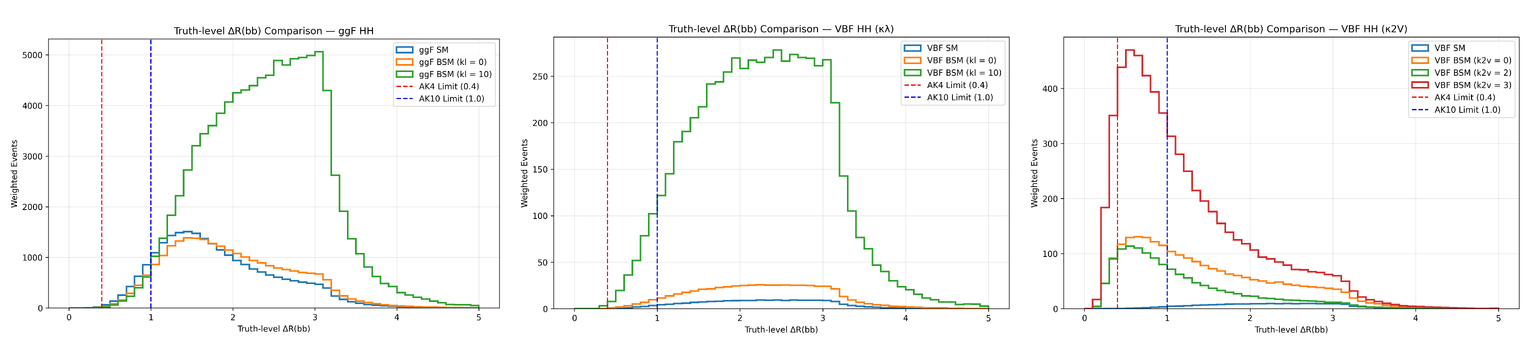

In [4]:
from IPython.display import Image
Image("compare_dR_all.png")

### Observation: Fraction of events below ΔR(bb) thresholds

To quantify the boosted fraction of each sample, I calculated the fraction of 
truth-level events falling below two ΔR(bb) thresholds, using generator weights:

- **ΔR < 0.4** — events so collimated that two small-radius (AK4) jets would 
  merge and could not be resolved (lost by the standard resolved analysis).
- **ΔR < 1.0** — a looser threshold indicating events collimated enough that a 
  large-radius (AK10) boosted analysis could recover them.

**Results:**

| Sample | < 0.4 | < 1.0 |
|---|---|---|
| ggF SM | 0.09% | 9.89% |
| ggF (kl = 0) | 0.05% | 6.69% |
| ggF (kl = 10) | 0.01% | 1.53% |
| VBF SM | 0.09% | 4.87% |
| VBF (kl = 0) | 0.06% | 4.81% |
| VBF (kl = 10) | 0.06% | 4.85% |
| VBF (k2v = 0) | 6.30% | 39.27% |
| VBF (k2v = 2) | 10.13% | 53.81% |

The ggF and VBF κλ scenarios have a negligible fraction of 
collimated events (~0% below ΔR = 0.4), confirming they are dominated by resolved 
topologies. In contrast, the VBF κ2V scenarios show a large boosted fraction, for 
κ2V = 2, over half the events (53.8%) fall below ΔR = 1 and ~10% below ΔR = 0.4. 
This reinforces that boosted HH topologies are driven by the Higgs–vector-boson 
couplings (κ2V), and that a boosted analysis is most beneficial for these scenarios.


ggF SM: 0.09% < 0.4 | 9.89% < 1.0
ggF (kl = 0): 0.05% < 0.4 | 6.69% < 1.0
ggF (kl = 10): 0.01% < 0.4 | 1.53% < 1.0
VBF SM: 0.09% < 0.4 | 4.87% < 1.0
VBF (kl = 0): 0.06% < 0.4 | 4.81% < 1.0
VBF (kl = 10): 0.06% < 0.4 | 4.85% < 1.0
VBF (k2v = 0): 6.30% < 0.4 | 39.27% < 1.0
VBF (k2v = 2): 10.13% < 0.4 | 53.81% < 1.0


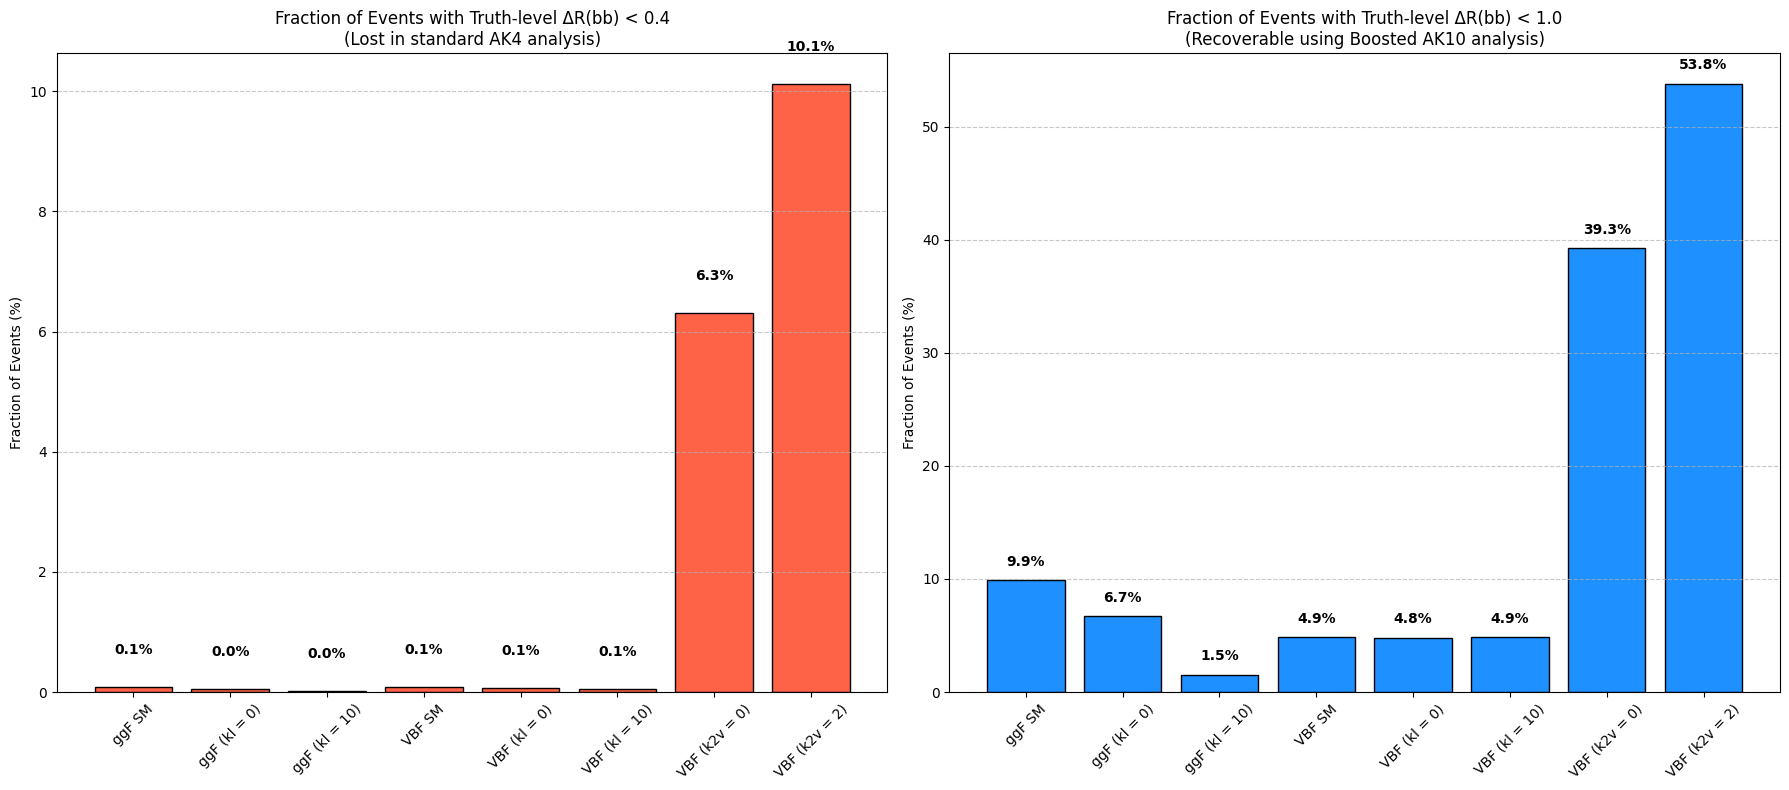

In [2]:
all_samples = {
    "ggF SM":        ggF_samples["ggF SM"],
    "ggF (kl = 0)":  ggF_samples["ggF BSM (kl = 0)"],
    "ggF (kl = 10)": ggF_samples["ggF BSM (kl = 10)"],
    "VBF SM":        vbf_kappa_lambda_samples["VBF SM"],
    "VBF (kl = 0)":  vbf_kappa_lambda_samples["VBF BSM (kl = 0)"],
    "VBF (kl = 10)": vbf_kappa_lambda_samples["VBF BSM (kl = 10)"],
    "VBF (k2v = 0)": vbf_kappa_2v_samples["VBF BSM (k2v = 0)"],
    "VBF (k2v = 2)": vbf_kappa_2v_samples["VBF BSM (k2v = 2)"],
}

sample_names = []
fractions_04 = []
fractions_10 = []

for label, files in all_samples.items():
    dR_list, w_list = compute_truth_dR(files)   
    dR_array = np.array(dR_list)
    w_array = np.array(w_list)

    total_weight = np.sum(w_array)
    if total_weight > 0:
        frac_04 = np.sum(w_array[dR_array < 0.4]) / total_weight * 100.0
        frac_10 = np.sum(w_array[dR_array < 1.0]) / total_weight * 100.0
        sample_names.append(label)
        fractions_04.append(frac_04)
        fractions_10.append(frac_10)
        print(f"{label}: {frac_04:.2f}% < 0.4 | {frac_10:.2f}% < 1.0")
    else:
        print(f"{label}: no data!")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

bars1 = ax1.bar(sample_names, fractions_04, color='tomato', edgecolor='black')
ax1.set_ylabel("Fraction of Events (%)")
ax1.set_title("Fraction of Events with Truth-level ΔR(bb) < 0.4\n(Lost in standard AK4 analysis)")
ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax1.tick_params(axis='x', rotation=45)
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f"{yval:.1f}%", ha='center', va='bottom', fontweight='bold')

bars2 = ax2.bar(sample_names, fractions_10, color='dodgerblue', edgecolor='black')
ax2.set_ylabel("Fraction of Events (%)")
ax2.set_title("Fraction of Events with Truth-level ΔR(bb) < 1.0\n(Recoverable using Boosted AK10 analysis)")
ax2.grid(axis='y', linestyle='--', alpha=0.7)
ax2.tick_params(axis='x', rotation=45)
for bar in bars2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 1.0, f"{yval:.1f}%", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig("fractions_bar_plots.png", dpi=300)
plt.show()